In [1]:
import pandas as pd

In [2]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  

from sklearn.impute import SimpleImputer  
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  

import scipy.stats as stats  
import statsmodels.api as sm  

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 50)  

sns.set(style="whitegrid")  

%matplotlib inline

In [3]:
df = pd.read_excel('Vertical Progressions & Transitional Threat Analysis.xlsx')
print(df)

               Club  TotalPassCmp  TotalPassAtt  TotPassCmp%  TotalPassDist   
0           Arsenal         15412         18278         84.3         252697  \
1       Aston Villa         13346         16095         82.9         228211   
2       Bournemouth         11327         14883         76.1         204901   
3         Brentford         11963         15323         78.1         219510   
4          Brighton         14216         17243         82.4         241867   
5           Chelsea         16566         19510         84.9         286368   
6    Crystal Palace         10754         14232         75.6         193429   
7           Everton          9995         13212         75.7         189249   
8            Fulham         14589         17830         81.8         260056   
9      Ipswich Town         10100         13039         77.5         179917   
10   Leicester City         12593         15813         79.6         210895   
11        Liverpool         16368         19473     

In [8]:
df.head()

,Club,TotalPassCmp,TotalPassAtt,TotPassCmp%,TotalPassDist,PrgPassDist,ShortPassCmp,ShortPassAtt,ShortPassCmp%,MedPassCmp,MedPassAtt,MedPassCmp%,LongPassCmp,LongPassAtt,LongPassCmp%,Ast,xAG,xA,A-xAG,KeyPass,PassFinal3rd,PassPenA,CrsPenA,PrgPass,LivePass,DeadPass,PassFreeKick,TroughBalls,Switches,Crosses,TriughInsTaken,CornerKicks,InswinningCK,OutswinningCK,StrCK,PassesCmp,PassesOffside,PassesBlocks
0,Arsenal,15412,18278,84.3,252697,78773,7724,8427,91.7,6475,7266,89.1,947,1834,51.6,50,40.4,40.8,9.6,377,1253,393,66,1655,16807,1396,385,68,69,700,543,230,198,3,2,15412,75,250
1,Aston Villa,13346,16095,82.9,228211,79269,6169,6825,90.4,5953,6687,89.0,961,1810,53.1,41,38.6,33.4,2.4,329,1028,287,51,1197,14519,1526,516,83,48,546,453,213,141,21,1,13346,50,316
2,Bournemouth,11327,14883,76.1,204901,77212,4904,5697,86.1,4942,5858,84.4,1212,2533,47.8,38,40.8,32.9,-2.8,404,1098,299,90,1332,13290,1530,382,52,69,746,621,208,154,17,3,11327,63,277
3,Brentford,11963,15323,78.1,219510,84201,5246,6057,86.6,5198,6135,84.7,1294,2440,53.0,39,37.3,34.3,1.7,296,987,290,80,1197,13845,1416,353,59,60,600,524,153,120,2,0,11963,62,256
4,Brighton,14216,17243,82.4,241867,81970,6868,7601,90.4,5862,6706,87.4,1194,2162,55.2,36,36.3,34.5,-0.3,331,1067,303,80,1380,15738,1465,443,66,71,623,550,169,98,41,6,14216,40,275


In [9]:
df.describe()

,TotalPassCmp,TotalPassAtt,TotPassCmp%,TotalPassDist,PrgPassDist,ShortPassCmp,ShortPassAtt,ShortPassCmp%,MedPassCmp,MedPassAtt,MedPassCmp%,LongPassCmp,LongPassAtt,LongPassCmp%,Ast,xAG,xA,A-xAG,KeyPass,PassFinal3rd,PassPenA,CrsPenA,PrgPass,LivePass,DeadPass,PassFreeKick,TroughBalls,Switches,Crosses,TriughInsTaken,CornerKicks,InswinningCK,OutswinningCK,StrCK,PassesCmp,PassesOffside,PassesBlocks
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,13499.350000,16590.650000,80.905000,231961.650000,80001.200000,6342.850000,7071.550000,89.360000,5743.550000,6560.10000,87.145000,1116.000000,2163.050000,51.660000,36.350000,36.220000,32.210000,0.130000,334.150000,1055.750000,284.400000,67.800000,1257.750000,15057.100000,1475.100000,414.200000,58.100000,75.60000,598.900000,558.450000,175.750000,106.600000,33.350000,3.350000,13499.350000,58.450000,289.300000
std,2508.379625,2380.508753,3.628466,37337.348972,7112.449557,1372.581903,1382.755733,2.055391,1149.146204,1139.54381,2.742929,143.823723,236.933141,4.468298,11.721662,8.964527,8.103339,6.039876,64.569241,209.749694,69.102822,13.237109,270.798405,2378.016155,73.328317,45.313644,15.430319,24.53011,90.927328,54.518442,40.034032,31.493358,21.648569,4.221187,2508.379625,12.596888,34.838122
min,9419.000000,12582.000000,74.900000,160702.000000,65376.000000,4413.000000,5115.000000,85.700000,3430.000000,4276.00000,80.200000,914.000000,1793.000000,43.800000,15.000000,21.100000,18.500000,-9.400000,225.000000,761.000000,147.000000,44.000000,816.000000,11069.000000,1384.000000,353.000000,27.000000,39.00000,442.000000,439.000000,118.000000,63.000000,2.000000,0.000000,9419.000000,39.000000,243.000000
25%,11804.000000,15213.000000,77.950000,209396.500000,75834.000000,5160.500000,5967.000000,88.000000,5126.500000,5894.75000,84.925000,999.750000,2011.250000,49.525000,24.750000,30.350000,25.925000,-4.875000,293.500000,889.750000,240.250000,59.250000,1039.750000,13706.250000,1425.750000,385.000000,49.750000,54.75000,541.500000,531.500000,137.750000,87.750000,18.000000,0.000000,11804.000000,49.000000,271.500000
50%,13573.500000,16518.000000,81.650000,230659.000000,79617.000000,6315.500000,7026.500000,89.650000,5824.000000,6641.00000,87.750000,1107.000000,2156.500000,52.150000,38.500000,36.800000,32.450000,0.700000,331.000000,1012.500000,289.500000,65.000000,1232.000000,14981.000000,1459.500000,398.000000,55.500000,70.00000,587.000000,552.000000,174.500000,99.500000,27.000000,1.500000,13573.500000,58.000000,282.000000
75%,15088.000000,18221.750000,83.425000,253636.500000,84818.750000,7207.250000,7974.250000,90.575000,6489.250000,7304.25000,89.025000,1225.500000,2292.500000,54.375000,44.500000,40.950000,35.675000,4.900000,365.750000,1204.750000,332.750000,80.000000,1424.500000,16728.750000,1514.000000,440.750000,69.000000,92.75000,630.750000,610.750000,212.250000,118.500000,43.750000,4.500000,15088.000000,66.250000,304.250000
max,19263.000000,21833.000000,88.200000,312666.000000,93682.000000,9899.000000,10663.000000,92.800000,7985.000000,8700.00000,91.800000,1361.000000,2596.000000,62.500000,59.000000,54.700000,48.300000,9.600000,462.000000,1495.000000,393.000000,93.000000,1711.000000,20388.000000,1707.000000,516.000000,83.000000,120.00000,812.000000,627.000000,233.000000,198.000000,84.000000,14.000000,19263.000000,82.000000,399.000000


In [10]:
df.isnull()

,Club,TotalPassCmp,TotalPassAtt,TotPassCmp%,TotalPassDist,PrgPassDist,ShortPassCmp,ShortPassAtt,ShortPassCmp%,MedPassCmp,MedPassAtt,MedPassCmp%,LongPassCmp,LongPassAtt,LongPassCmp%,Ast,xAG,xA,A-xAG,KeyPass,PassFinal3rd,PassPenA,CrsPenA,PrgPass,LivePass,DeadPass,PassFreeKick,TroughBalls,Switches,Crosses,TriughInsTaken,CornerKicks,InswinningCK,OutswinningCK,StrCK,PassesCmp,PassesOffside,PassesBlocks
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Progressive Pass Distance per Team

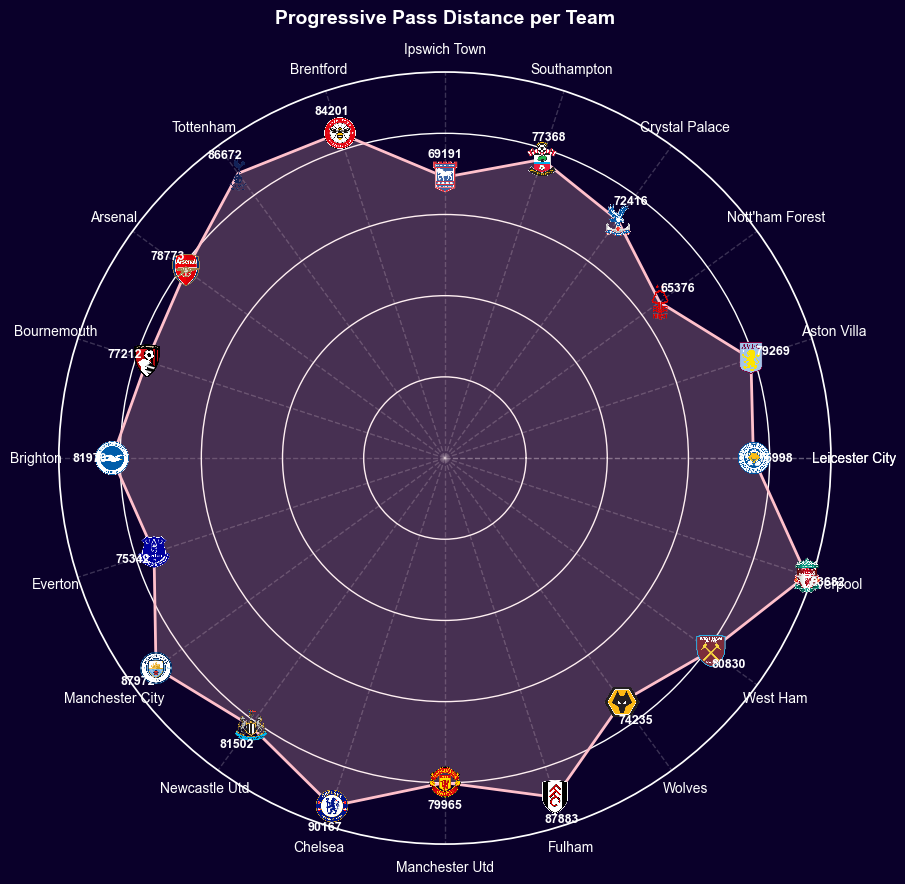

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

teams = df['Club']
prg_pass_dist = df['PrgPassDist'].values
num_vars = len(teams)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
prg_pass_dist = np.append(prg_pass_dist, prg_pass_dist[0])
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#0A002A')  
fig.patch.set_facecolor('#0A002A') 

ax.plot(angles, prg_pass_dist, color='pink', linewidth=2)
ax.fill(angles, prg_pass_dist, color='pink', alpha=0.25)

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i in range(num_vars):
    logo_path = os.path.join(logos_path, f"{teams.iloc[i]}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.09)
        ab = AnnotationBbox(imagebox, (angles[i], prg_pass_dist[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)
    
    ax.text(
        angles[i], prg_pass_dist[i] + max(prg_pass_dist)*0.06,
        f"{int(prg_pass_dist[i])}",
        ha='center', va='center',
        color='white', fontsize=9, weight='bold'
    )

teams_list = list(teams)
teams_list.append(teams_list[0])
ax.set_xticks(angles)
ax.set_xticklabels(teams_list, color='white', fontsize=10)

ax.set_yticklabels([])
ax.xaxis.grid(True, color='white', linestyle='--', alpha=0.2)
plt.title('Progressive Pass Distance per Team', color='white', fontsize=14, weight='bold', pad=35)

plt.tight_layout()
plt.show()

Switches vs Final Third Passes per Team

In [33]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [37]:
print(df[['Switches', 'PassesOffside']].describe())
print(df[['Switches', 'PassesOffside']].isna().sum())

        Switches  PassesOffside
count   20.00000      20.000000
mean    75.60000      58.450000
std     24.53011      12.596888
min     39.00000      39.000000
25%     54.75000      49.000000
50%     70.00000      58.000000
75%     92.75000      66.250000
max    120.00000      82.000000
Switches         0
PassesOffside    0
dtype: int64


In [39]:
df = df[(df['Switches'] < 10000) & (df['PassesOffside'] < 10000)]

In [ ]:
import os
from PIL import Image


logo_directory = r'D:\Work\Data Analysis TFA\04 Vertical Progressions & Transitional Threat Analysis\logos'

for filename in os.listdir(logo_directory):
    if filename.endswith('.png'):
        try:
            image_path = os.path.join(logo_directory, filename)
            with Image.open(image_path) as img:
                width, height = img.size
                print(f"Image: {filename}, Width: {width}, Height: {height}")
        except Exception as e:
            print(f"Error with image {filename}: {e}")

Image: Arsenal.png, Width: 300, Height: 300
Image: Aston Villa.png, Width: 300, Height: 300
Image: Bournemouth.png, Width: 300, Height: 300
Image: Brentford.png, Width: 300, Height: 300
Image: Brighton.png, Width: 300, Height: 300
Image: Chelsea.png, Width: 300, Height: 300
Image: Crystal Palace.png, Width: 300, Height: 300
Image: Everton.png, Width: 300, Height: 300
Image: Fulham.png, Width: 300, Height: 300
Image: Ipswich Town.png, Width: 300, Height: 300
Image: Leicester City.png, Width: 300, Height: 300
Image: Liverpool.png, Width: 300, Height: 300
Image: Manchester City.png, Width: 300, Height: 300
Image: Manchester Utd.png, Width: 300, Height: 300
Image: Newcastle Utd.png, Width: 300, Height: 300
Image: Nott'ham Forest.png, Width: 300, Height: 300
Image: Southampton.png, Width: 300, Height: 300
Image: Tottenham.png, Width: 300, Height: 300
Image: West Ham.png, Width: 300, Height: 300
Image: Wolves.png, Width: 300, Height: 300


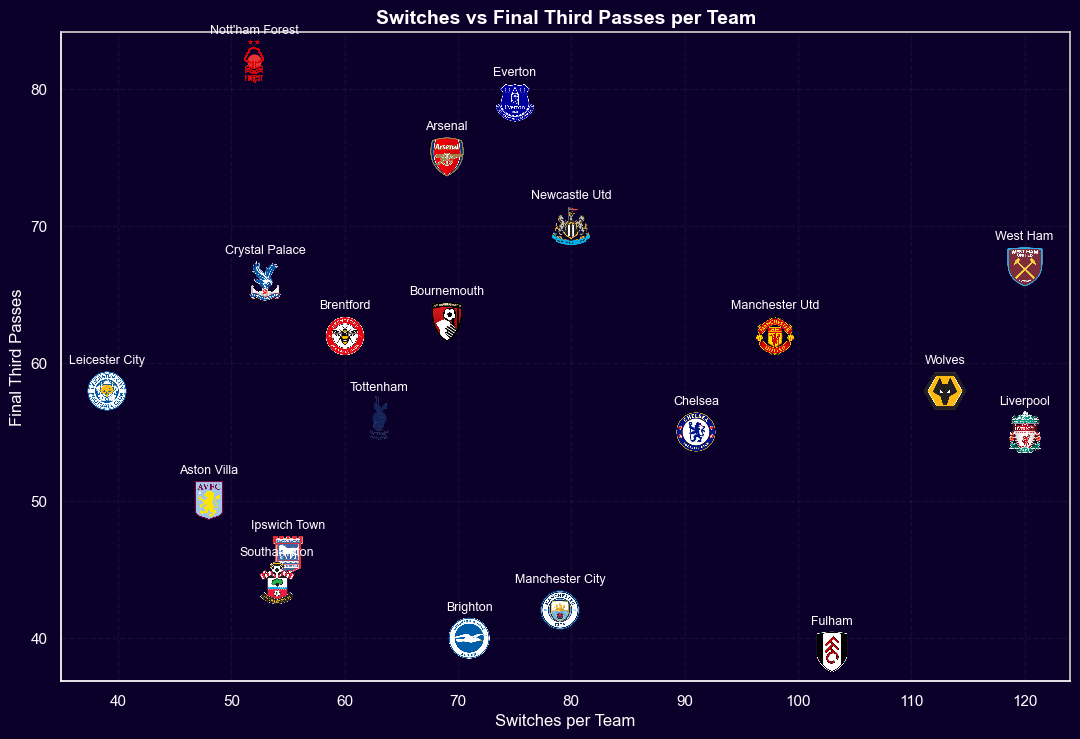

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

df = df.dropna(subset=['Switches', 'PassesOffside']) 
df['Switches'] = pd.to_numeric(df['Switches'], errors='coerce')  
df['PassesOffside'] = pd.to_numeric(df['PassesOffside'], errors='coerce')
df = df[(df['Switches'] < 10000) & (df['PassesOffside'] < 10000)] 

teams = df['Club']
x = df['Switches']
y = df['PassesOffside']

team_colors = {
    'Arsenal': '#DB0007',
    'Aston Villa': '#95BFE5',
    'Bournemouth': '#DA291C',
    'Brentford': '#E30613',
    'Brighton': '#0057B8',
    'Chelsea': '#034694',
    'Crystal Palace': '#1B458F',
    'Everton': '#003399',
    'Fulham': '#000000',
    'Ipswich Town': '#0057B8',
    'Leicester City': '#003090',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD',
    'Manchester Utd': '#DA291C',
    'Newcastle Utd': '#241F20',
    "Nott'ham Forest": '#E53233',
    'Southampton': '#D71920',
    'Tottenham': '#132257',
    'West Ham': '#7A263A',
    'Wolves': '#FDB913'
}

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    color = team_colors.get(team, 'white')  
    ax.scatter(x.iloc[i], y.iloc[i], color=color, s=150, edgecolors='#0A002A', linewidths=2)

    logo_path = os.path.join(logos_path, f"{team}.png")
    
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.11)  
        ab = AnnotationBbox(imagebox, (x.iloc[i], y.iloc[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)

    ax.text(x.iloc[i], y.iloc[i] + 2, team, fontsize=9, color='white', ha='center')

ax.set_xlabel('Switches per Team', color='white', fontsize=12)
ax.set_ylabel('Final Third Passes', color='white', fontsize=12)
ax.set_title('Switches vs Final Third Passes per Team', color='white', fontsize=14, weight='bold')

ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05)

plt.tight_layout()
plt.show()

Decoding Pass Profiles: Average Completion Rates for Short, Medium, and Long Passes

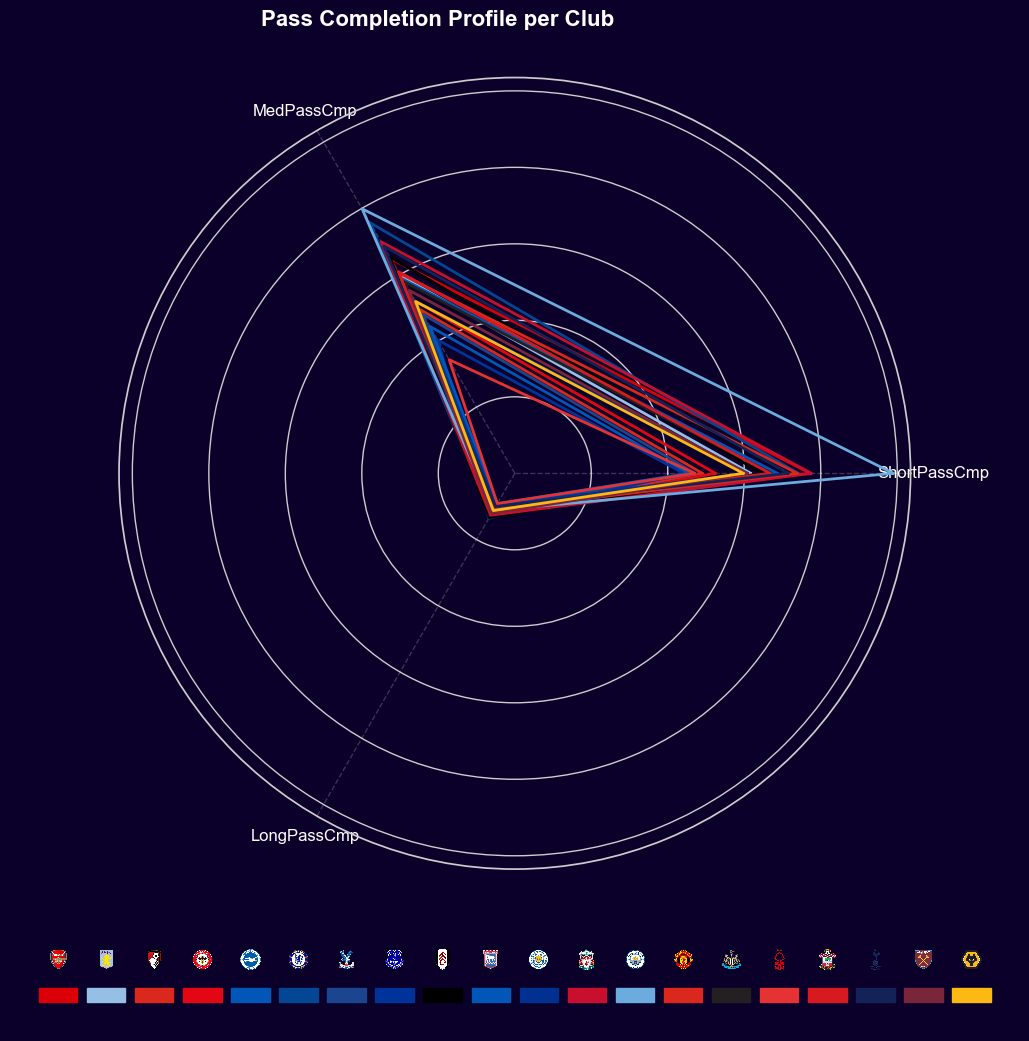

In [29]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

categories = ['ShortPassCmp', 'MedPassCmp', 'LongPassCmp']
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('#0A002A')

gs = fig.add_gridspec(6, 6)
polar_ax = fig.add_subplot(gs[:-1, :], polar=True)
logo_ax = fig.add_subplot(gs[-1, :])
polar_ax.set_facecolor('#0A002A')
logo_ax.set_facecolor('#0A002A')

team_colors = {
    'Arsenal': '#DB0007',
    'Aston Villa': '#95BFE5',
    'Bournemouth': '#DA291C',
    'Brentford': '#E30613',
    'Brighton': '#0057B8',
    'Chelsea': '#034694',
    'Crystal Palace': '#1B458F',
    'Everton': '#003399',
    'Fulham': '#000000',
    'Ipswich Town': '#0057B8',
    'Leicester City': '#003090',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD',
    'Manchester Utd': '#DA291C',
    'Newcastle Utd': '#241F20',
    "Nott'ham Forest": '#E53233',
    'Southampton': '#D71920',
    'Tottenham': '#132257',
    'West Ham': '#7A263A',
    'Wolves': '#FDB913'
}

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"
zoom = 0.055

for idx, row in df.iterrows():
    values = row[categories].values
    values = np.append(values, values[0])
    club = row['Club']
    color = team_colors.get(club, 'white')
    polar_ax.plot(angles, values, color=color, linewidth=2)

polar_ax.set_xticks(angles[:-1])
polar_ax.set_xticklabels(categories, color='white', fontsize=12)
polar_ax.set_yticklabels([])
polar_ax.xaxis.grid(True, color='white', linestyle='--', alpha=0.2)

logo_ax.axis('off')
for idx, club in enumerate(df['Club']):
    logo_path = os.path.join(logos_path, f"{club}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path).convert("RGBA")
        imagebox = OffsetImage(logo_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (idx, 0.5), frameon=False)
        logo_ax.add_artist(ab)
        logo_ax.add_patch(plt.Rectangle((idx - 0.4, 0.2), 0.8, 0.1, color=team_colors.get(club, 'white'), transform=logo_ax.transData))

logo_ax.set_xlim(-1, len(df['Club']))
logo_ax.set_ylim(0, 1)

fig.suptitle('Pass Completion Profile per Club', color='white', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Switch It Up: How Switches of Play Shape Final Third Entries

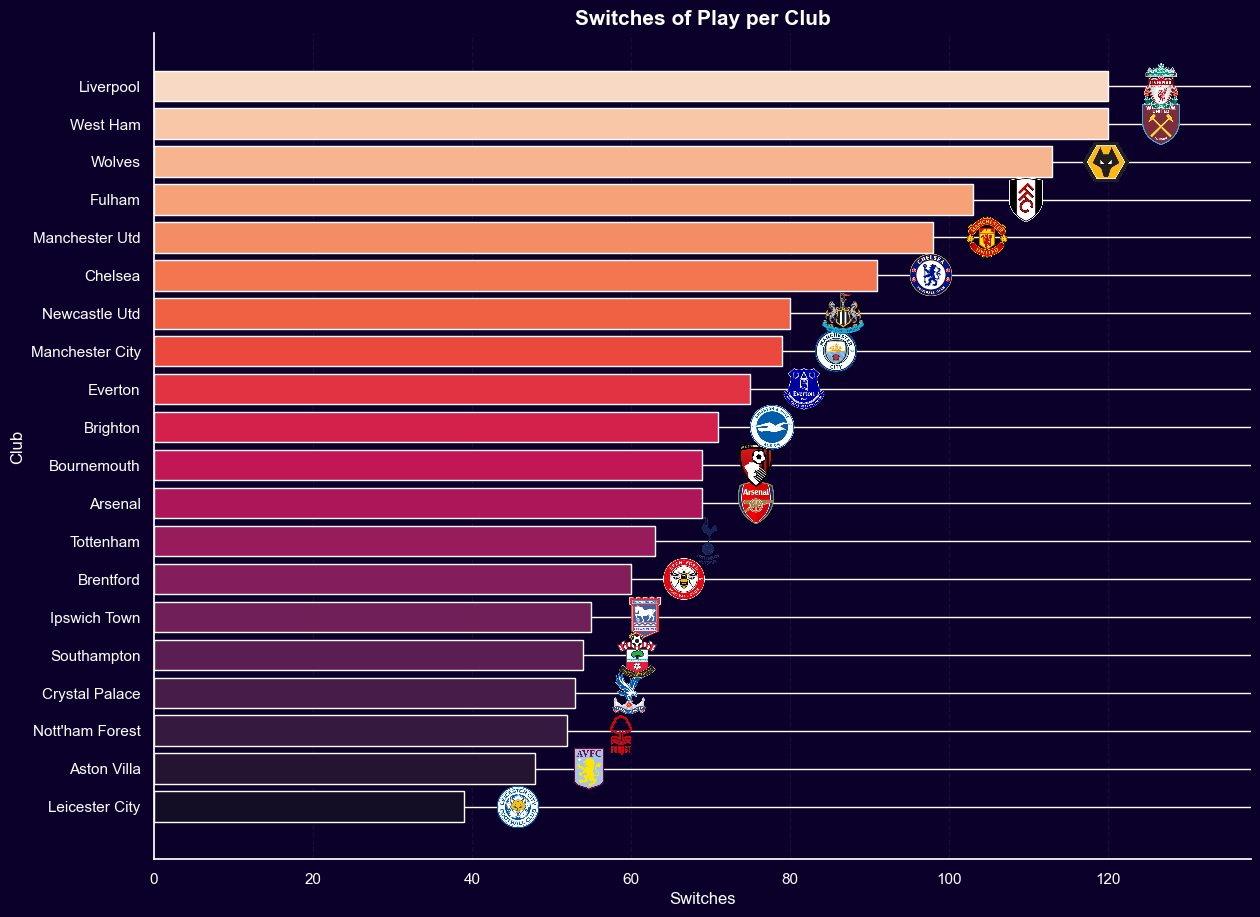

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

df = df.dropna(subset=['Switches'])
df['Switches'] = pd.to_numeric(df['Switches'], errors='coerce')
df = df[df['Switches'] < 10000]

df = df.sort_values('Switches', ascending=True)
teams = df['Club']
switches = df['Switches']

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"
colors = sns.color_palette("rocket", n_colors=len(teams))

bars = ax.barh(teams, switches, color=colors)

max_switch = switches.max()

for i, team in enumerate(teams):
    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.12)
        ab = AnnotationBbox(imagebox, (switches.iloc[i] + max_switch * 0.03, i), frameon=False, box_alignment=(0, 0.5), zorder=10)
        ax.add_artist(ab)

ax.set_xlim(0, max_switch + max_switch * 0.15)

ax.set_title('Switches of Play per Club', color='white', fontsize=15, weight='bold')
ax.set_xlabel('Switches', color='white')
ax.set_ylabel('Club', color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05, axis='x')

plt.tight_layout()
plt.show()

Threading the Needle: Through Balls as Predictors of Expected Goals

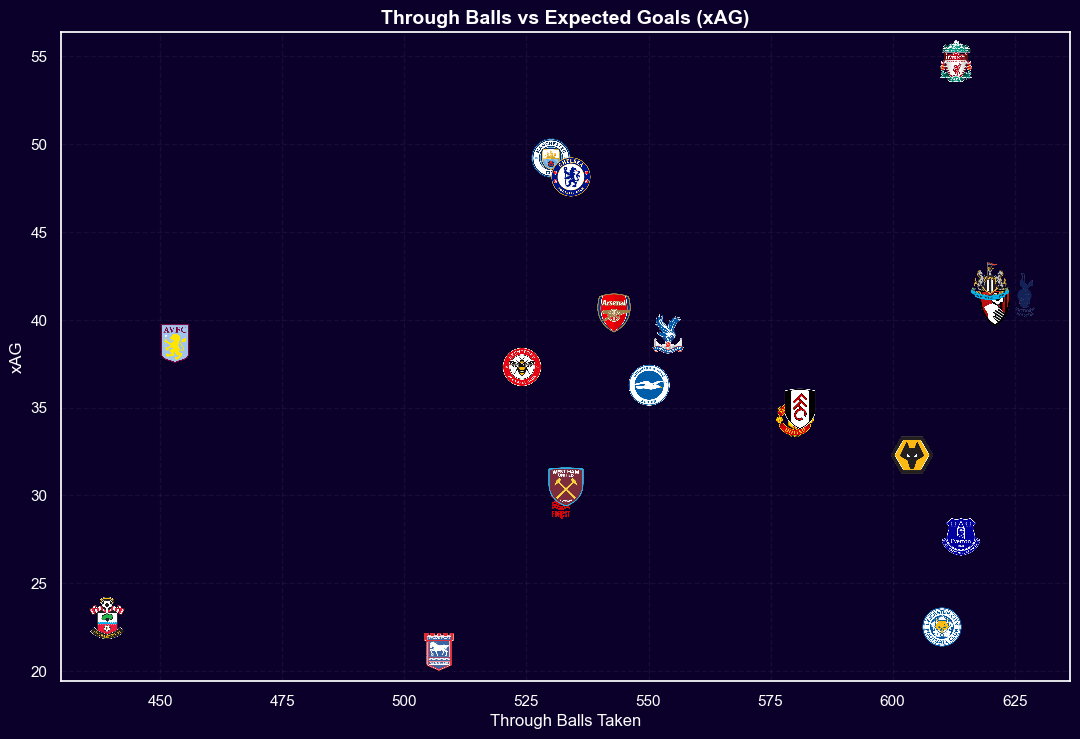

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

x = df['TriughInsTaken']
y = df['xAG']
teams = df['Club']

team_colors = {
    'Arsenal': '#DB0007',
    'Aston Villa': '#95BFE5',
    'Bournemouth': '#DA291C',
    'Brentford': '#E30613',
    'Brighton': '#0057B8',
    'Chelsea': '#034694',
    'Crystal Palace': '#1B458F',
    'Everton': '#003399',
    'Fulham': '#000000',
    'Ipswich Town': '#0057B8',
    'Leicester City': '#003090',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD',
    'Manchester Utd': '#DA291C',
    'Newcastle Utd': '#241F20',
    "Nott'ham Forest": '#E53233',
    'Southampton': '#D71920',
    'Tottenham': '#132257',
    'West Ham': '#7A263A',
    'Wolves': '#FDB913'
}

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    color = team_colors.get(team, 'white')
    ax.scatter(x.iloc[i], y.iloc[i], color=color, s=150, edgecolors='#0A002A', linewidths=2)

    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.11)
        ab = AnnotationBbox(imagebox, (x.iloc[i], y.iloc[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)


ax.set_xlabel('Through Balls Taken', color='white', fontsize=12)
ax.set_ylabel('xAG', color='white', fontsize=12)
ax.set_title('Through Balls vs Expected Goals (xAG)', color='white', fontsize=14, weight='bold')

ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05)

plt.tight_layout()
plt.show()


Cross Accuracy and Creative Output: Examining the Link to xA

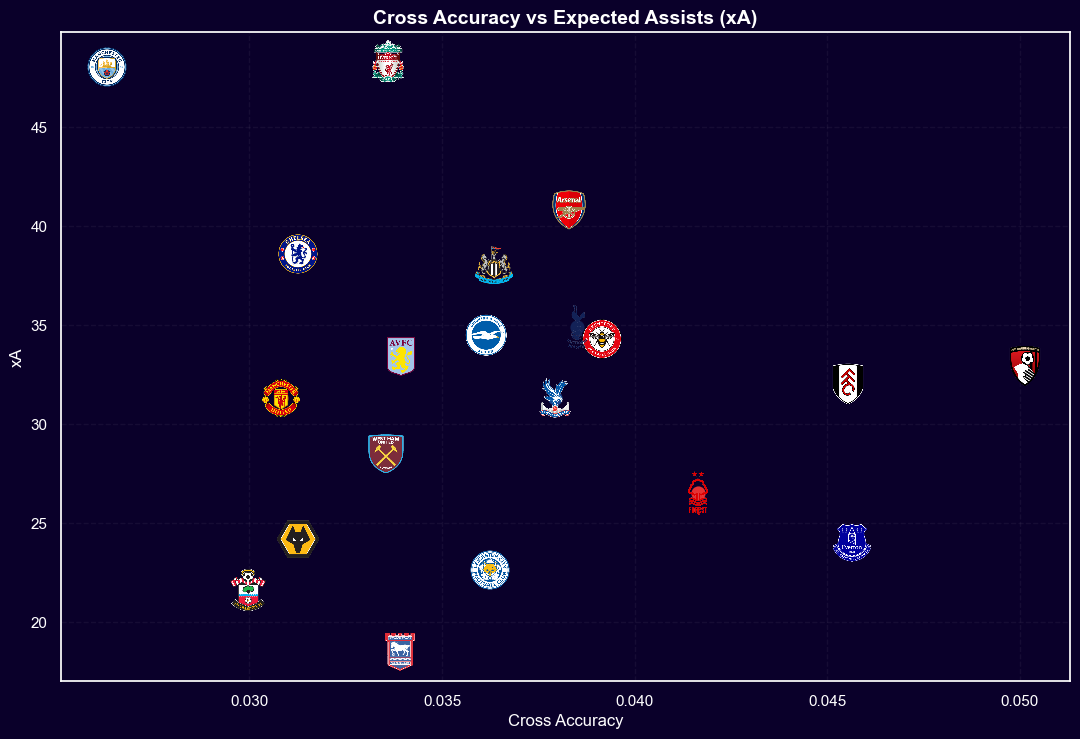

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

df['CrossAccuracy'] = df['Crosses'] / df['TotalPassAtt']
x = df['CrossAccuracy']
y = df['xA']
teams = df['Club']

team_colors = {
    'Arsenal': '#DB0007',
    'Aston Villa': '#95BFE5',
    'Bournemouth': '#DA291C',
    'Brentford': '#E30613',
    'Brighton': '#0057B8',
    'Chelsea': '#034694',
    'Crystal Palace': '#1B458F',
    'Everton': '#003399',
    'Fulham': '#000000',
    'Ipswich Town': '#0057B8',
    'Leicester City': '#003090',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD',
    'Manchester Utd': '#DA291C',
    'Newcastle Utd': '#241F20',
    "Nott'ham Forest": '#E53233',
    'Southampton': '#D71920',
    'Tottenham': '#132257',
    'West Ham': '#7A263A',
    'Wolves': '#FDB913'
}


fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    color = team_colors.get(team, 'white')
    ax.scatter(x.iloc[i], y.iloc[i], color=color, s=150, edgecolors='#0A002A', linewidths=2)

    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.11)
        ab = AnnotationBbox(imagebox, (x.iloc[i], y.iloc[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)


ax.set_xlabel('Cross Accuracy', color='white', fontsize=12)
ax.set_ylabel('xA', color='white', fontsize=12)
ax.set_title('Cross Accuracy vs Expected Assists (xA)', color='white', fontsize=14, weight='bold')

ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05)

plt.tight_layout()
plt.show()


 Attacking Identity: Radar Comparison of xA and xAG per Team

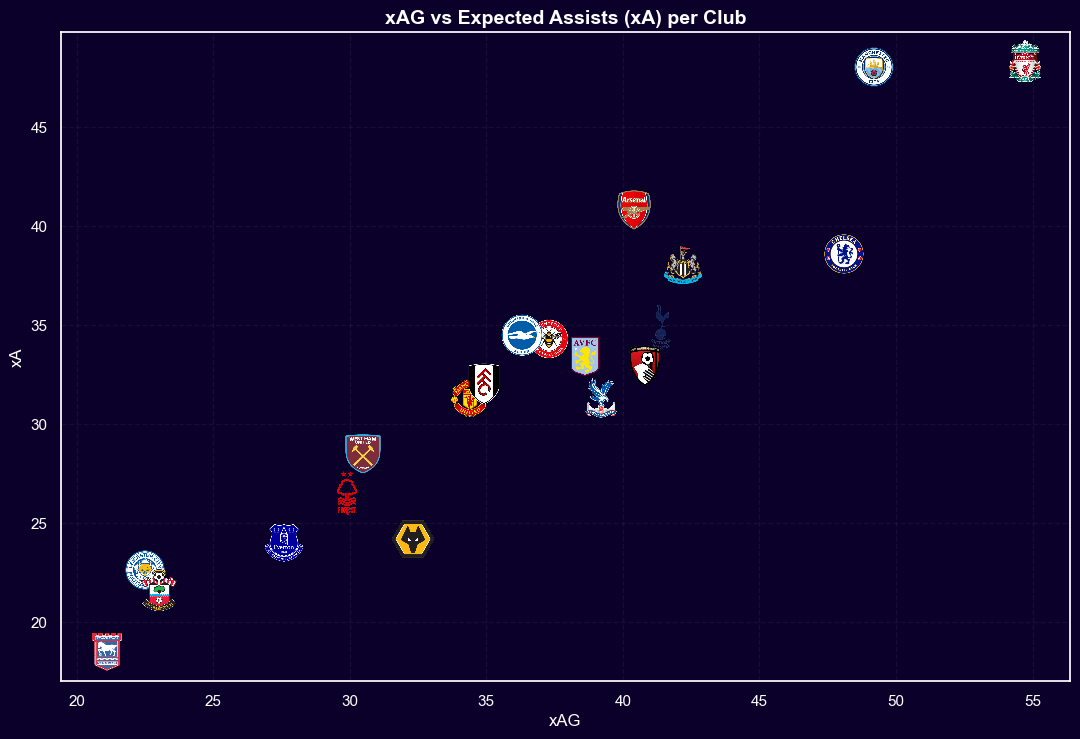

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

x = df['xAG']
y = df['xA']
teams = df['Club']

team_colors = {
    'Arsenal': '#DB0007',
    'Aston Villa': '#95BFE5',
    'Bournemouth': '#DA291C',
    'Brentford': '#E30613',
    'Brighton': '#0057B8',
    'Chelsea': '#034694',
    'Crystal Palace': '#1B458F',
    'Everton': '#003399',
    'Fulham': '#000000',
    'Ipswich Town': '#0057B8',
    'Leicester City': '#003090',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD',
    'Manchester Utd': '#DA291C',
    'Newcastle Utd': '#241F20',
    "Nott'ham Forest": '#E53233',
    'Southampton': '#D71920',
    'Tottenham': '#132257',
    'West Ham': '#7A263A',
    'Wolves': '#FDB913'
}

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    color = team_colors.get(team, 'white')
    ax.plot(x.iloc[i], y.iloc[i], 'o', color=color, markersize=0)  
    
    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.11)
        ab = AnnotationBbox(imagebox, (x.iloc[i], y.iloc[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)

ax.set_xlabel('xAG', color='white', fontsize=12)
ax.set_ylabel('xA', color='white', fontsize=12)
ax.set_title('xAG vs Expected Assists (xA) per Club', color='white', fontsize=14, weight='bold')

ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05)

plt.tight_layout()
plt.show()

 Progressive Powerhouses: Top 5 Teams by Progressive Pass Distance

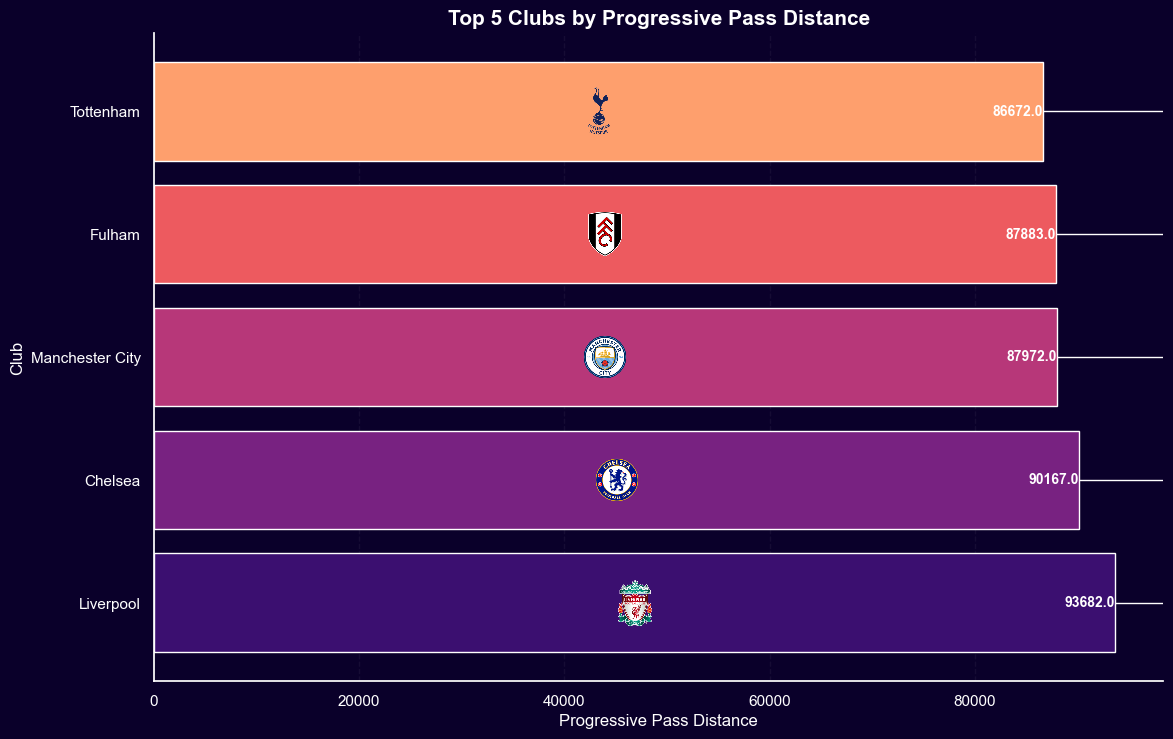

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

top5 = df.sort_values('PrgPassDist', ascending=False).head(5)
teams = top5['Club']
values = top5['PrgPassDist']

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

colors = plt.cm.magma(np.linspace(0.2, 0.8, len(top5)))

bars = ax.barh(teams, values, color=colors)

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.12)
        ab = AnnotationBbox(imagebox, (values.iloc[i] / 2, i), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)

    ax.text(values.iloc[i] - 25, i, f"{values.iloc[i]:.1f}", color='white', fontsize=10, fontweight='bold', va='center', ha='right')

ax.set_title('Top 5 Clubs by Progressive Pass Distance', color='white', fontsize=15, weight='bold')
ax.set_xlabel('Progressive Pass Distance', color='white')
ax.set_ylabel('Club', color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05, axis='x')

plt.tight_layout()
plt.show()


 Passing DNA: Clustering Teams by Pass Types and xAG

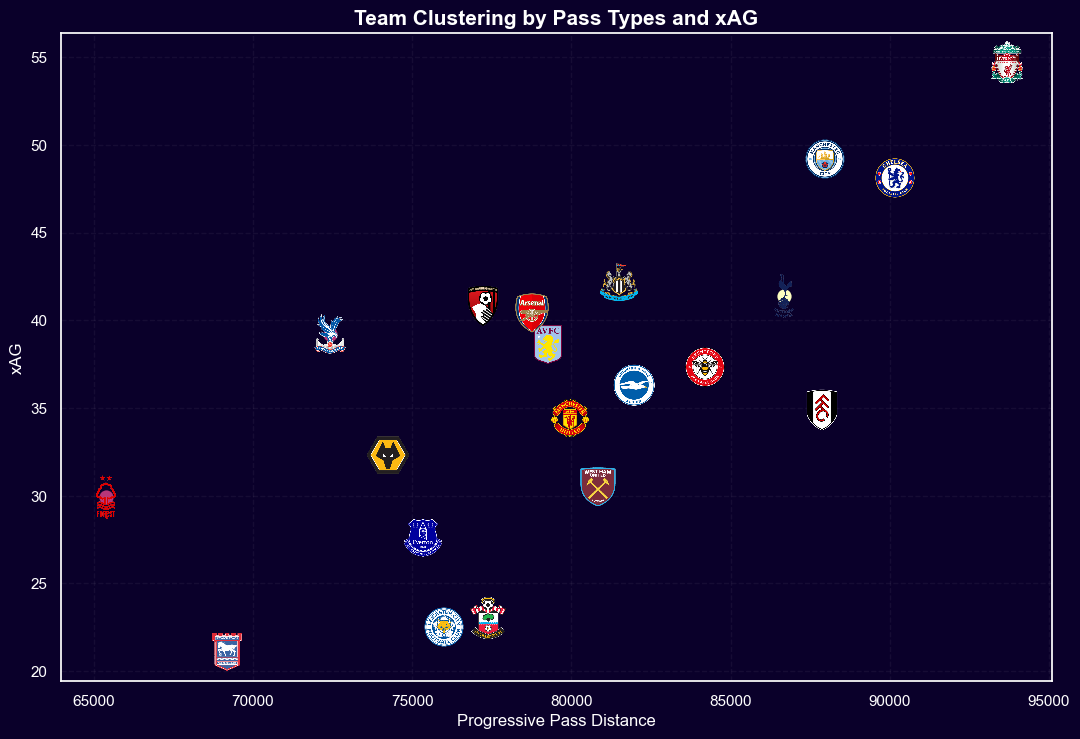

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.cluster import KMeans

X = df[['ShortPassCmp', 'MedPassCmp', 'LongPassCmp', 'PrgPassDist']]
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
df['Cluster'] = kmeans.labels_

x = df['PrgPassDist']
y = df['xAG']
teams = df['Club']

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0A002A')
fig.patch.set_facecolor('#0A002A')

colors = plt.cm.magma(df['Cluster'] / df['Cluster'].max())

logos_path = "D:/Work/Data Analysis TFA/04 Vertical Progressions & Transitional Threat Analysis/logos/"

for i, team in enumerate(teams):
    ax.scatter(x.iloc[i], y.iloc[i], color=colors[i], s=150, edgecolors='#0A002A', linewidths=2)

    logo_path = os.path.join(logos_path, f"{team}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path)
        imagebox = OffsetImage(logo_img, zoom=0.11)
        ab = AnnotationBbox(imagebox, (x.iloc[i], y.iloc[i]), frameon=False, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)

ax.set_title('Team Clustering by Pass Types and xAG', color='white', fontsize=15, weight='bold')
ax.set_xlabel('Progressive Pass Distance', color='white')
ax.set_ylabel('xAG', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.grid(color='white', linestyle='--', alpha=0.05)

plt.tight_layout()
plt.show()
